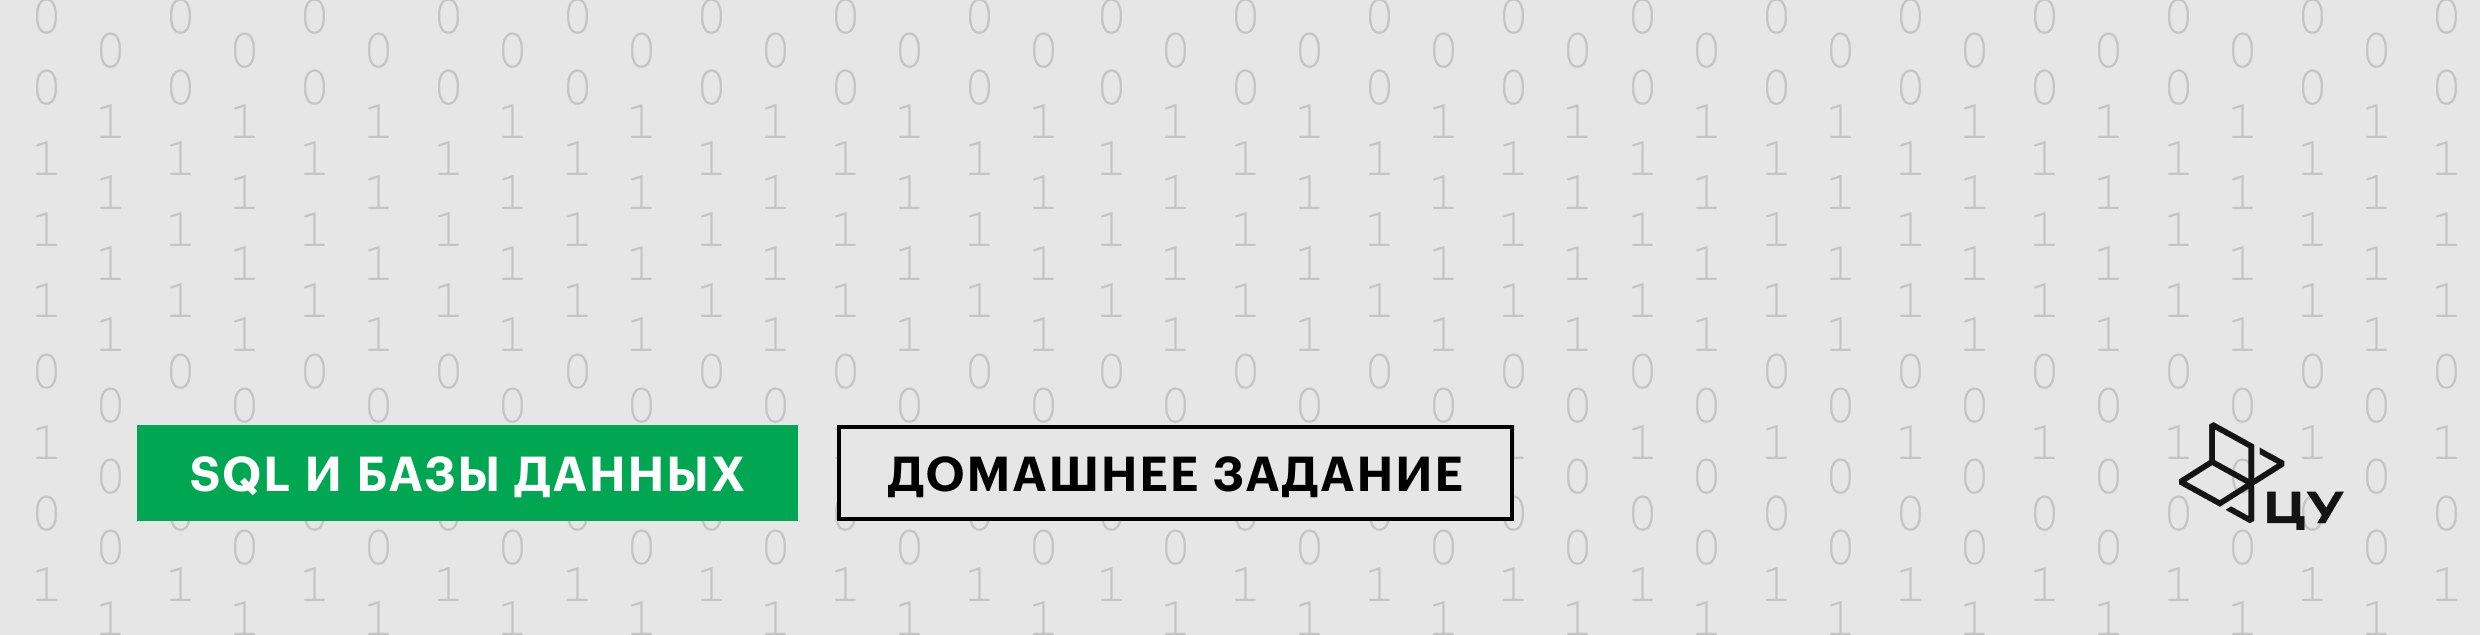

# Домашнее задание по теме Разработка запросов к одной таблице

Мы подготовили для тебя задачи, которые помогут закрепить пройденный материал.

В задании нужно написать запросы SQL к базе данных, которая используется в курсе. Описание таблиц и схему БД можно посмотреть тут:

https://centraluniversity.yonote.ru/share/0188ee4d-d0bb-4654-9d49-87dab28e9550/doc/tablicy-ispolzuemye-v-kurse-sql-i-bazy-dannyh-kXDYWB70FN


Подготовленное решение (данный файл) нужно сдать на проверку.


In [15]:
import os,requests,time;url = "http://sql-exercise.sql-exercise-prod.svc.cluster.local/"
if os.path.exists("py_workshop.py"):
    os.remove("py_workshop.py")
if not os.path.exists("py_workshop.py"):
    response = requests.get(f"{url}get_py_workshop")
    if response.status_code == 200: 
        with open("py_workshop.py", "wb") as f: f.write(response.content);time.sleep(1)
# Проверь, что config.yaml (надо заполнить по инструкции) и py_workshop.py (скачается автоматически) находятся в папке с этим ноутбуком
from py_workshop import *;runner.set_url(url);runner.logon();schema_name = runner.user_schema

runner.course = 'sql'
runner.material( 'sqldb_an26_single_table_hw', course_launch='dbsql_an_onl_26_fall')

# Часть 1. Введение в SQL и базы данных

### Задача 1. Таблицы pizza и pizza_order с ключами (баллы: 0.5)
Все задания курса можно полностью выполнить в Jupyter Notebook. При желании можно использовать клиентское программное обеспечение, например DBeaver.

В этом задании ты создашь таблицы `pizza` и `pizza_order` в своей схеме PostgreSQL. В заготовке уже настроены первичные ключи и внешний ключ из `pizza_order.pizza_id` в `pizza.pizza_id`.

Скопируй SQL-код из описания в ячейку **DDL и DML код**. Замени каждую заглушку вместе с квадратными скобками на подходящий SQL-код или значение.

```sql
DROP TABLE IF EXISTS {schema_name}.pizza_order;
DROP TABLE IF EXISTS {schema_name}.pizza;

CREATE TABLE {schema_name}.pizza (
    pizza_id INTEGER PRIMARY KEY,
    pizza_name TEXT NOT NULL,
    price NUMERIC(10, 2) NOT NULL
);

CREATE TABLE {schema_name}.pizza_order (
    order_id INTEGER PRIMARY KEY,
    pizza_id INTEGER NOT NULL REFERENCES {schema_name}.pizza(pizza_id),
    order_time TIMESTAMP WITH TIME ZONE NOT NULL,
    [ОПРЕДЕЛЕНИЕ СТОЛБЦА quantity ЦЕЛОЧИСЛЕННОГО ТИПА]
);

INSERT INTO {schema_name}.pizza (pizza_id, pizza_name, price)
VALUES
    (1, 'Margherita', 500.50),
    (2, 'Pepperoni', 650.00),
    (3, 'Hawaiian', 700.75),
    (4, 'Four Cheese', 750.00),
    (5, 'Meat Feast', 850.00),
    (6, '[НАЗВАНИЕ ШЕСТОЙ ПИЦЦЫ]', [ЦЕНА ШЕСТОЙ ПИЦЦЫ]);

INSERT INTO {schema_name}.pizza_order (order_id, pizza_id, order_time, quantity)
VALUES
    (1, 1, TIMESTAMP WITH TIME ZONE '2026-08-01 12:00:00+03', [КОЛИЧЕСТВО В ПЕРВОМ ЗАКАЗЕ]),
    (2, 2, TIMESTAMP WITH TIME ZONE '2026-08-01 12:30:00+03', [КОЛИЧЕСТВО ВО ВТОРОМ ЗАКАЗЕ]),
    (3, [СУЩЕСТВУЮЩИЙ pizza_id], TIMESTAMP WITH TIME ZONE '[ДАТА И ВРЕМЯ ТРЕТЬЕГО ЗАКАЗА С ЧАСОВЫМ ПОЯСОМ]', [КОЛИЧЕСТВО В ТРЕТЬЕМ ЗАКАЗЕ]);
```

**Что нужно сделать?**

1. В DDL таблицы `pizza_order` замени заглушку определением столбца `quantity` целочисленного типа.
2. В DML таблицы `pizza` задай название и цену шестой пиццы.
3. В DML таблицы `pizza_order` укажи количество для двух готовых заказов.
4. Заполни заглушки третьего заказа: выбери существующий `pizza_id`, дату и время с часовым поясом и количество.

После выполнения задания в таблице `pizza` должно быть не менее шести строк, а в `pizza_order` — не менее трёх строк.



In [27]:
%%exec_sql cell_1_1
-- DDL и DML код. Указывай правильную схему. Соединение postgres 
DROP TABLE IF EXISTS  d_churikov.pizza_order;
DROP TABLE IF EXISTS d_churikov.pizza;

CREATE TABLE d_churikov.pizza (
    pizza_id INTEGER PRIMARY KEY,
    pizza_name TEXT NOT NULL,
    price NUMERIC(10, 2) NOT NULL
);

CREATE TABLE d_churikov.pizza_order (
    order_id INTEGER PRIMARY KEY,
    pizza_id INTEGER NOT NULL REFERENCES d_churikov.pizza(pizza_id),
    order_time TIMESTAMP WITH TIME ZONE NOT NULL,
    quantity INTEGER
);

INSERT INTO d_churikov.pizza (pizza_id, pizza_name, price)
VALUES
    (1, 'Margherita', 500.50),
    (2, 'Pepperoni', 650.00),
    (3, 'Hawaiian', 700.75),
    (4, 'Four Cheese', 750.00),
    (5, 'Meat Feast', 850.00),
    (6, 'Double Pepperoni', 700.00);

INSERT INTO d_churikov.pizza_order (order_id, pizza_id, order_time, quantity)
VALUES
    (1, 1, TIMESTAMP WITH TIME ZONE '2026-08-01 12:00:00+03', 1),
    (2, 2, TIMESTAMP WITH TIME ZONE '2026-08-01 12:30:00+03', 2),
    (3, 3, TIMESTAMP WITH TIME ZONE '2026-08-01 12:40:00+03', 3);


OK (rowcount=-1)


In [28]:
%%sql_query cell_1_2
-- Задача 1. Ячейка 2. Запросы SQL Select. Соединение postgres 
select 1;

,?column?
0,1


In [29]:
%%sql_db_check_submit cell_1_3
--Проверка БД для задачи 1. Проверка содержимого БД
--Запусти ячейку для проверки
select * from d_churikov.pizza_order limit 1

✅ 100% Все проверки пройдены


# Часть 2. Разработка запросов к одной таблице

### Задача 2. Выборка строк из таблицы клиентов (баллы: 0.5)
Выведи 10 строк из таблицы shop_customers. Нужно вывести все столбцы в том порядке, в котором они идут в таблице.

Используй таблицы:
- shop_customers.



In [58]:
%%sql_query cell_2_1
-- Задача 2. Ячейка 1. Напиши SQL-запрос. Соединение postgres 

SELECT * from shop_customers limit 10;

,customer_id,first_name,last_name,email,phone_number,created_at
0,5,Агафья,Лебедева,ernstemeljanov@gmail.com,+7 (205) 091-6096,2024-07-21 11:18:04.416
1,6,Пров,Осипов,popovaakulina@hotmail.com,8 (085) 644-9254,2023-06-03 15:41:47.003
2,10,София,Суворов,borislav_68@rambler.ru,89801646038,2023-01-03 09:45:52.275
3,11,Ираклий,Филатова,maksimzaharov@rambler.ru,8 (362) 962-8913,2024-10-05 19:04:12.478
4,13,Селиван,Евдокимова,samolovstepan@mail.ru,8 (477) 079-10-71,2023-11-12 02:58:22.792
5,14,Феврония,Буров,arseni35@yahoo.com,8 581 015 20 66,2023-03-06 20:52:02.020
6,21,Венедикт,Доронина,braginairaida@yahoo.com,86396570479,2024-01-03 16:51:47.481
7,25,Виктория,Панфилова,antonina_36@rambler.ru,8 530 346 17 42,2024-10-09 17:39:16.815
8,32,Никон,Устинов,ermakovsvjatoslav@yandex.ru,+7 638 044 73 92,2023-03-27 09:40:44.881
9,52,Татьяна,Наумов,silanti_39@yahoo.com,+71902261779,2024-10-13 23:14:32.875


In [57]:
%%sql_query_submit cell_2_2
--Проверка запроса для задачи 2. Отправь SQL-запрос на проверку
SELECT * from shop_customers limit 10;



✅Результат совпадает с выводом эталонного решения!✅



,customer_id,first_name,last_name,email,phone_number,created_at
index,,,,,,
0,5,Агафья,Лебедева,ernstemeljanov@gmail.com,+7 (205) 091-6096,2024-07-21T11:18:04.416
1,6,Пров,Осипов,popovaakulina@hotmail.com,8 (085) 644-9254,2023-06-03T15:41:47.003
2,10,София,Суворов,borislav_68@rambler.ru,89801646038,2023-01-03T09:45:52.275
3,11,Ираклий,Филатова,maksimzaharov@rambler.ru,8 (362) 962-8913,2024-10-05T19:04:12.478
4,13,Селиван,Евдокимова,samolovstepan@mail.ru,8 (477) 079-10-71,2023-11-12T02:58:22.792
5,14,Феврония,Буров,arseni35@yahoo.com,8 581 015 20 66,2023-03-06T20:52:02.020
6,21,Венедикт,Доронина,braginairaida@yahoo.com,86396570479,2024-01-03T16:51:47.481
7,25,Виктория,Панфилова,antonina_36@rambler.ru,8 530 346 17 42,2024-10-09T17:39:16.815
8,32,Никон,Устинов,ermakovsvjatoslav@yandex.ru,+7 638 044 73 92,2023-03-27T09:40:44.881


### Задача 3. Уникальные статусы заказов (баллы: 0.5)
Выведи все уникальные статусы заказов из таблицы shop_orders. Отсортируй значения по возрастанию.

Результат должен содержать столбцы:
- **unique_order_status** — статус заказа.

Используй таблицы:
- shop_orders.



In [56]:
%%sql_query cell_3_1
-- Задача 3. Ячейка 1. Напиши SQL-запрос. Соединение postgres 
SELECT distinct order_status as unique_order_status 
    FROM shop_orders 
    ORDER BY order_status asc


,unique_order_status
0,Cancelled
1,Completed
2,Pending
3,Processing
4,Refunded


In [40]:
%%sql_query_submit cell_3_2
--Проверка запроса для задачи 3. Отправь SQL-запрос на проверку
SELECT distinct order_status as unique_order_status 
    FROM shop_orders 
    ORDER BY order_status asc



✅Результат совпадает с выводом эталонного решения!✅



,unique_order_status
index,
0,Cancelled
1,Completed
2,Pending
3,Processing
4,Refunded
,unique_order_status
index,
0,Cancelled
1,Completed


### Задача 4. Дата первого заказа (баллы: 0.5)
В таблице shop_orders нужно найти дату создания первого заказа.

Результат должен содержать столбцы:
- **order_date** — дата первого заказа.

Используй таблицы:
- shop_orders.



In [59]:
%%sql_query cell_4_1
-- Задача 4. Ячейка 1. Напиши SQL-запрос. Соединение postgres 
SELECT MIN (order_date) as order_date 
    from shop_orders

,order_date
0,2023-01-01


In [54]:
%%sql_query_submit cell_4_2
--Проверка запроса для задачи 4. Отправь SQL-запрос на проверку
SELECT MIN (order_date) as order_date 
    from shop_orders



✅Результат совпадает с выводом эталонного решения!✅



,order_date
index,
0,2023-01-01T00:00:00.000
,order_date
index,
0,2023-01-01T00:00:00.000


### Задача 5. Дата последнего заказа (баллы: 1)
В таблице shop_orders нужно найти дату создания последнего заказа.

Результат должен содержать столбцы:
- **order_date** — дата заказа.

Используй таблицы:
- shop_orders.



In [53]:
%%sql_query cell_5_1
-- Задача 5. Ячейка 1. Напиши SQL-запрос. Соединение postgres 
SELECT MAX (order_date) as order_date 
    from shop_orders

,order_date
0,2024-12-02


In [60]:
%%sql_query_submit cell_5_2
--Проверка запроса для задачи 5. Отправь SQL-запрос на проверку
SELECT MAX (order_date) as order_date 
    from shop_orders



✅Результат совпадает с выводом эталонного решения!✅



,order_date
index,
0,2024-12-02T00:00:00.000
,order_date
index,
0,2024-12-02T00:00:00.000


### Задача 6. Топ-5 самых дорогих заказов (баллы: 1)
Из таблицы shop_orders выведи пять самых дорогих заказов.

Результат должен содержать столбцы:
- **order_id** — идентификатор заказа;
- **order_date** — дата заказа;
- **total_amount** — сумма заказа.

Используй таблицы:
- shop_orders.



In [51]:
%%sql_query cell_6_1
-- Задача 6. Ячейка 1. Напиши SQL-запрос. Соединение postgres 
SELECT order_id, order_date , total_amount 
    from shop_orders 
    ORDER BY total_amount desc 
    LIMIT 5

,order_id,order_date,total_amount
0,74982,2023-02-03,834950.0
1,33870,2024-08-16,739960.0
2,385,2023-01-15,725940.0
3,1331,2024-04-02,719960.0
4,63393,2024-03-20,719960.0


In [61]:
%%sql_query_submit cell_6_2
--Проверка запроса для задачи 6. Отправь SQL-запрос на проверку
SELECT order_id, order_date , total_amount 
    from shop_orders 
    ORDER BY total_amount desc 
    LIMIT 5



✅Результат совпадает с выводом эталонного решения!✅



,order_id,order_date,total_amount
index,,,
0,74982,2023-02-03T00:00:00.000,834950.000000
1,33870,2024-08-16T00:00:00.000,739960.000000
2,385,2023-01-15T00:00:00.000,725940.000000
3,1331,2024-04-02T00:00:00.000,719960.000000
4,63393,2024-03-20T00:00:00.000,719960.000000
,order_id,order_date,total_amount
index,,,
0,74982,2023-02-03T00:00:00.000,834950.000000
1,33870,2024-08-16T00:00:00.000,739960.000000


### Задача 7. Поиск клиентов с Gmail (баллы: 1)
Из таблицы shop_customers найди 10 клиентов, адрес электронной почты которых находится на домене gmail.com.

Результат должен содержать столбцы:
- **customer_id** — идентификатор клиента;
- **email** — адрес электронной почты клиента;
- **created_at** — дата и время создания записи.

Используй таблицы:
- shop_customers.



In [73]:
%%sql_query cell_7_1
-- Задача 7. Ячейка 1. Напиши SQL-запрос. Соединение postgres 
SELECT customer_id,email,created_at from shop_customers
    WHERE 
            1=1
        and email LIKE '%gmail.com'
    LIMIT 10

,customer_id,email,created_at
0,5,ernstemeljanov@gmail.com,2024-07-21 11:18:04.416
1,62,beljakovtvorimir@gmail.com,2023-06-18 12:40:09.556
2,73,kazimir19@gmail.com,2024-04-05 23:09:26.486
3,111,sazonovavtonom@gmail.com,2024-04-08 09:52:42.977
4,117,eleonora62@gmail.com,2024-03-08 08:19:08.904
5,137,tihon_98@gmail.com,2023-02-05 15:12:25.825
6,145,nikon_2010@gmail.com,2023-07-15 13:01:56.512
7,156,nadezhda_11@gmail.com,2024-07-12 20:23:37.530
8,186,spiridon_1976@gmail.com,2024-06-03 05:03:17.710
9,210,frolovkir@gmail.com,2024-04-08 15:46:18.629


In [74]:
%%sql_query_submit cell_7_2
--Проверка запроса для задачи 7. Отправь SQL-запрос на проверку
SELECT customer_id,email,created_at from shop_customers
    WHERE 
            1=1
        and email LIKE '%gmail.com'
    LIMIT 10



✅Результат совпадает с выводом эталонного решения!✅



,customer_id,email,created_at
index,,,
0,5,ernstemeljanov@gmail.com,2024-07-21T11:18:04.416
1,62,beljakovtvorimir@gmail.com,2023-06-18T12:40:09.556
2,73,kazimir19@gmail.com,2024-04-05T23:09:26.486
3,111,sazonovavtonom@gmail.com,2024-04-08T09:52:42.977
4,117,eleonora62@gmail.com,2024-03-08T08:19:08.904
5,137,tihon_98@gmail.com,2023-02-05T15:12:25.825
6,145,nikon_2010@gmail.com,2023-07-15T13:01:56.512
7,156,nadezhda_11@gmail.com,2024-07-12T20:23:37.530
8,186,spiridon_1976@gmail.com,2024-06-03T05:03:17.710


### Задача 8. Дорогие и дешёвые товары (баллы: 1)
Из таблицы shop_products выведи информацию о дорогих и дешёвых товарах нашего магазина.
Дешёвыми считай товары стоимостью менее 10 000, а дорогими — товары стоимостью более 300 000.

Результат должен содержать столбцы:
- **product_id** — идентификатор товара;
- **price** — стоимость товара;
- **name** — название товара.

Используй таблицы:
- shop_products.



In [87]:
%%sql_query cell_8_1
-- Задача 8. Ячейка 1. Напиши SQL-запрос. Соединение postgres 
SELECT product_id,price,name  from shop_products
    WHERE 
        1=1 
        and (price < 10000
        or price > 300000)

,product_id,price,name
0,24,9990.0,Xiaomi Mi Watch
1,25,329990.0,Canon EOS R5
2,32,7990.0,Sega Mega Drive Mini
3,52,3490.0,Xiaomi Mi Band 6
4,19,5990.0,JBL Tune 500BT
5,41,9990.0,Logitech MX Master 3
6,38,7990.0,HyperX Cloud II
7,40,5990.0,Apple Magic Mouse


In [88]:
%%sql_query_submit cell_8_2
--Проверка запроса для задачи 8. Отправь SQL-запрос на проверку
SELECT product_id,price,name  from shop_products
    WHERE 
        1=1 
        and (price < 10000
        or price > 300000)



✅Результат совпадает с выводом эталонного решения!✅



,product_id,price,name
index,,,
0,19,5990.000000,JBL Tune 500BT
1,24,9990.000000,Xiaomi Mi Watch
2,25,329990.000000,Canon EOS R5
3,32,7990.000000,Sega Mega Drive Mini
4,38,7990.000000,HyperX Cloud II
5,40,5990.000000,Apple Magic Mouse
6,41,9990.000000,Logitech MX Master 3
7,52,3490.000000,Xiaomi Mi Band 6
,product_id,price,name


### Задача 9. Товары за декабрь 2022 (баллы: 1)
Из таблицы shop_products выведи товары, относящиеся к категории с идентификатором 1 и созданные в декабре 2022 года.

Результат должен содержать столбцы:
- **product_id** — идентификатор товара;
- **price** — стоимость товара;
- **name** — название товара;
- **created_at** — дата и время создания товара.

Используй таблицы:
- shop_products.



In [92]:
%%sql_query cell_9_1
-- Задача 9. Ячейка 1. Напиши SQL-запрос. Соединение postgres 
SELECT product_id,price,name,created_at  from shop_products
WHERE 
    created_at between '2022-12-01' and '2023-01-01'
    and category_id=1

,product_id,price,name,created_at
0,3,199990.0,"Sony Bravia 75""",2022-12-12 08:35:50
1,4,39990.0,"Xiaomi Mi TV 4A 43""",2022-12-30 09:37:58


In [93]:
%%sql_query_submit cell_9_2
--Проверка запроса для задачи 9. Отправь SQL-запрос на проверку
SELECT product_id,price,name,created_at  from shop_products
WHERE 
    created_at between '2022-12-01' and '2023-01-01'
    and category_id=1



✅Результат совпадает с выводом эталонного решения!✅



,product_id,price,name,created_at
index,,,,
0,3,199990.000000,"Sony Bravia 75""",2022-12-12T08:35:50.000
1,4,39990.000000,"Xiaomi Mi TV 4A 43""",2022-12-30T09:37:58.000
,product_id,price,name,created_at
index,,,,
0,3,199990.000000,"Sony Bravia 75""",2022-12-12T08:35:50.000
1,4,39990.000000,"Xiaomi Mi TV 4A 43""",2022-12-30T09:37:58.000


### Задача 10. Полное имя клиента одной строкой (баллы: 1)
Из таблицы shop_customers выведи информацию о клиентах.

Результат должен содержать столбцы:
- **customer_id** — идентификатор клиента;
- **first_name** — имя клиента;
- **last_name** — фамилия клиента;
- **full_name** — имя и фамилия клиента, разделённые пробелом.

Используй таблицы:
- shop_customers.



In [96]:
%%sql_query cell_10_1
-- Задача 10. Ячейка 1. Напиши SQL-запрос. Соединение postgres 
SELECT customer_id, first_name, last_name, first_name || ' ' || last_name as full_name
 from shop_customers

,customer_id,first_name,last_name,full_name
0,5,Агафья,Лебедева,Агафья Лебедева
1,6,Пров,Осипов,Пров Осипов
2,10,София,Суворов,София Суворов
3,11,Ираклий,Филатова,Ираклий Филатова
4,13,Селиван,Евдокимова,Селиван Евдокимова
5,14,Феврония,Буров,Феврония Буров
6,21,Венедикт,Доронина,Венедикт Доронина
7,25,Виктория,Панфилова,Виктория Панфилова
8,32,Никон,Устинов,Никон Устинов
9,52,Татьяна,Наумов,Татьяна Наумов


In [97]:
%%sql_query_submit cell_10_2
--Проверка запроса для задачи 10. Отправь SQL-запрос на проверку
SELECT customer_id, first_name, last_name, first_name || ' ' || last_name as full_name
 from shop_customers



✅Результат совпадает с выводом эталонного решения!✅



,customer_id,first_name,last_name,full_name
index,,,,
0,5,Агафья,Лебедева,Агафья Лебедева
1,6,Пров,Осипов,Пров Осипов
2,10,София,Суворов,София Суворов
3,11,Ираклий,Филатова,Ираклий Филатова
4,13,Селиван,Евдокимова,Селиван Евдокимова
5,14,Феврония,Буров,Феврония Буров
6,21,Венедикт,Доронина,Венедикт Доронина
7,25,Виктория,Панфилова,Виктория Панфилова
8,32,Никон,Устинов,Никон Устинов


### Задача 11. Заказы с долгой доставкой (баллы: 1)
Из таблицы shop_orders выведи завершённые заказы (order_status = 'Completed'), созданные 10 июля 2024 года и доставленные более чем за пять дней.

Результат должен содержать столбцы:
- **order_id** — идентификатор заказа;
- **customer_id** — идентификатор клиента;
- **order_date** — дата заказа;
- **delivery_date** — дата доставки.

Используй таблицы:
- shop_orders.



In [100]:
%%sql_query cell_11_1
-- Задача 11. Ячейка 1. Напиши SQL-запрос. Соединение postgres 
SELECT order_id, customer_id, order_date, delivery_date 
    from shop_orders
    WHERE 
        order_status = 'Completed'
        and order_date = '2024-07-10'
        and delivery_date > '2024-07-15'

,order_id,customer_id,order_date,delivery_date
0,7903,3985,2024-07-10,2024-07-18
1,23515,11895,2024-07-10,2024-07-16
2,57157,28735,2024-07-10,2024-07-17
3,45266,22838,2024-07-10,2024-07-17
4,27739,14017,2024-07-10,2024-07-16


In [101]:
%%sql_query_submit cell_11_2
--Проверка запроса для задачи 11. Отправь SQL-запрос на проверку
SELECT order_id, customer_id, order_date, delivery_date 
    from shop_orders
    WHERE 
        order_status = 'Completed'
        and order_date = '2024-07-10'
        and delivery_date > '2024-07-15'



✅Результат совпадает с выводом эталонного решения!✅



,order_id,customer_id,order_date,delivery_date
index,,,,
0,7903,3985,2024-07-10T00:00:00.000,2024-07-18T00:00:00.000
1,23515,11895,2024-07-10T00:00:00.000,2024-07-16T00:00:00.000
2,27739,14017,2024-07-10T00:00:00.000,2024-07-16T00:00:00.000
3,45266,22838,2024-07-10T00:00:00.000,2024-07-17T00:00:00.000
4,57157,28735,2024-07-10T00:00:00.000,2024-07-17T00:00:00.000
,order_id,customer_id,order_date,delivery_date
index,,,,
0,7903,3985,2024-07-10T00:00:00.000,2024-07-18T00:00:00.000
1,23515,11895,2024-07-10T00:00:00.000,2024-07-16T00:00:00.000


### Задача 12. Заказы за сентябрь 2024 (баллы: 1)
Из таблицы shop_orders выведи заказы, доставленные в сентябре 2024 года, сумма которых превышает 500 000.

Результат должен содержать столбцы:
- **order_id** — идентификатор заказа;
- **customer_id** — идентификатор клиента;
- **delivery_date** — дата доставки;
- **total_amount** — сумма заказа.

Используй таблицы:
- shop_orders.



In [102]:
%%sql_query cell_12_1
-- Задача 12. Ячейка 1. Напиши SQL-запрос. Соединение postgres 
SELECT order_id, customer_id, delivery_date,total_amount
    from shop_orders
    WHERE delivery_date between '2024-09-01' and '2024-10-01'
    and total_amount > 500000

,order_id,customer_id,delivery_date,total_amount
0,10029,5115,2024-09-10,539970.0
1,72320,36264,2024-09-25,524960.0
2,42702,21541,2024-09-24,519980.0
3,49925,25145,2024-09-08,539970.0
4,65082,32706,2024-09-05,509980.0
5,75383,37799,2024-09-01,559980.0


In [103]:
%%sql_query_submit cell_12_2
--Проверка запроса для задачи 12. Отправь SQL-запрос на проверку
SELECT order_id, customer_id, delivery_date,total_amount
    from shop_orders
    WHERE delivery_date between '2024-09-01' and '2024-10-01'
    and total_amount > 500000



✅Результат совпадает с выводом эталонного решения!✅



,order_id,customer_id,delivery_date,total_amount
index,,,,
0,10029,5115,2024-09-10T00:00:00.000,539970.000000
1,42702,21541,2024-09-24T00:00:00.000,519980.000000
2,49925,25145,2024-09-08T00:00:00.000,539970.000000
3,65082,32706,2024-09-05T00:00:00.000,509980.000000
4,72320,36264,2024-09-25T00:00:00.000,524960.000000
5,75383,37799,2024-09-01T00:00:00.000,559980.000000
,order_id,customer_id,delivery_date,total_amount
index,,,,
0,10029,5115,2024-09-10T00:00:00.000,539970.000000
